# DBSCAN 
## Density-Based Spatial Clustering of Applications with Noise
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups points based on density.
- It uses two parameters:
- ε (epsilon): maximum distance to consider points as neighbors.
- MinPts: minimum number of neighbors needed to form a cluster.

### Points are classified as:
- Core points: enough neighbors within ε.
- Border points: close to a core but not dense enough.
- Noise: isolated points, treated as outliers.
  
👉 Unlike K-Means, DBSCAN doesn’t need the number of clusters beforehand and can find clusters of arbitrary shapes, while also handling noise well.

- Density: number of points in an area
- High density point: a group which having high number of points 

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import  StandardScaler
from sklearn.datasets import load_iris

In [16]:
iris = load_iris()
x = iris.data

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

dbscan = DBSCAN(eps=0.6, min_samples=4)
dbscan.fit(x)

,eps,0.6
,min_samples,4
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


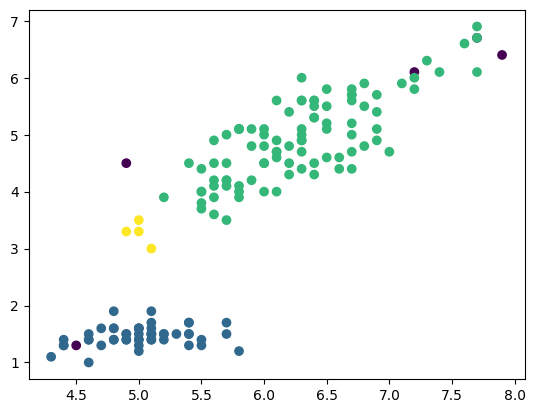

In [10]:
plt.scatter(x[:,0],x[:,2],c=dbscan.labels_)
plt.show()

min_samples=2, Silhouette Score=0.1904
min_samples=3, Silhouette Score=0.2591
min_samples=4, Silhouette Score=0.6550
min_samples=5, Silhouette Score=0.6559
min_samples=6, Silhouette Score=0.4659
min_samples=7, Silhouette Score=0.4360
min_samples=8, Silhouette Score=0.6029
min_samples=9, Silhouette Score=0.5394
min_samples=10, Silhouette Score=0.7101


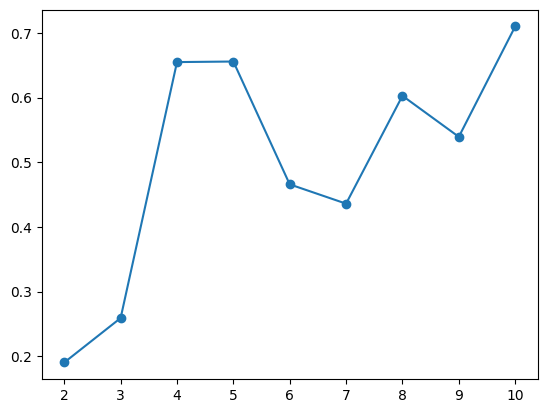

In [11]:
data = sns.load_dataset('iris')
features = data[['sepal_length','sepal_width','petal_length','petal_width']].values
feature = StandardScaler().fit_transform(features)

minpts_range = range(2,11)
silhouette = []
for n in minpts_range:
    dbscan = DBSCAN(eps=0.5,min_samples=n)
    model = dbscan.fit(feature)
    labels = model.labels_
    mask = labels != -1
    if len(set(labels[mask])) > 1 :
        score = silhouette_score(feature[mask],labels[mask])
        silhouette.append(score)
        print(f"min_samples={n}, Silhouette Score={score:.4f}")
    else:
        silhouette.append(0)
        print(f"min_samples={n}, Silhouette Score=Not valid")

plt.plot(minpts_range,silhouette, marker='o')
plt.show()